# MLOps Training 2026/2027 — Task 2
## Notebook 4: Exploratory Data Analysis
In this notebook, I will explore the training data to understand its structure, missing values, distributions, and patterns related to late delivery.

Only the training split will be used in this notebook. The validation and test sets will remain untouched.

The findings from this analysis will help decide which features to build in the next notebook.

## 1. Load the Training Data
I will load only the training split for the exploratory analysis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv(
    "artifacts/train.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

train.head()

Rows: 67533
Columns: 30


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_payment_value,max_installments,payment_type_count,seller_zip_code_prefix,seller_city,seller_state,seller_latitude,seller_longitude,distance_km,late_delivery
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,830d5b7aaa3b6f1e9ad63703bec97d23,14600,...,NaN,NaN,NaN,81810.0,curitiba,PR,-25.507014,-49.275963,565.959812,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,32ea3bdedab835c3aa6cb68ce66565ef,4106,...,45.46,1.0,1.0,85801.0,cascavel,PR,-24.959184,-53.462644,708.754247,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,2f64e403852e6893ae37485d5fcacdaf,98280,...,39.09,1.0,1.0,15802.0,catanduva,SP,-21.143389,-48.995314,915.912412,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,b8b8726af116a5cfb35b0315ecef9172,22770,...,35.61,1.0,1.0,5571.0,sao paulo,SP,-23.594556,-46.787489,357.574592,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,61db744d2f835035a5625b59350c6b63,90040,...,53.73,1.0,1.0,18015.0,sorocaba,SP,-23.502755,-47.430451,818.146504,0


## 2. Data Structure
I will check the column types and memory usage to understand what kind of data is available before starting the detailed analysis.

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67533 non-null  str           
 1   customer_id                    67533 non-null  str           
 2   order_status                   67533 non-null  str           
 3   order_purchase_timestamp       67533 non-null  datetime64[us]
 4   order_approved_at              67519 non-null  datetime64[us]
 5   order_delivered_carrier_date   67532 non-null  datetime64[us]
 6   order_delivered_customer_date  67533 non-null  datetime64[us]
 7   order_estimated_delivery_date  67533 non-null  datetime64[us]
 8   customer_unique_id             67533 non-null  str           
 9   customer_zip_code_prefix       67533 non-null  int64         
 10  customer_city                  67533 non-null  str           
 11  customer_state            

## 3. Missing Values
I will check how many values are missing in each column and what percentage of the training data they represent.

In [4]:
missing_values = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percentage": (train.isna().mean() * 100).round(2)
})

missing_values = (
    missing_values[missing_values["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

missing_values

,missing_count,missing_percentage
distance_km,345,0.51
customer_longitude,181,0.27
customer_latitude,181,0.27
seller_latitude,165,0.24
seller_longitude,165,0.24
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00
max_installments,1,0.00
total_payment_value,1,0.00
payment_count,1,0.00


### 3.1 Check the Missing Rows
The amount of missing data is very small. I will inspect these rows to understand whether the missing values are related to the order status or another pattern.

In [5]:
missing_rows = train[
    train[
        [
            "order_approved_at",
            "order_delivered_carrier_date",
            "payment_count",
            "total_payment_value",
            "max_installments",
            "payment_type_count"
        ]
    ].isna().any(axis=1)
]

missing_rows[
    [
        "order_id",
        "order_status",
        "order_approved_at",
        "order_delivered_carrier_date",
        "payment_count",
        "total_payment_value",
        "max_installments",
        "payment_type_count",
        "late_delivery"
    ]
]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,payment_count,total_payment_value,max_installments,payment_type_count,late_delivery
0,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-11-07 17:11:53,NaN,NaN,NaN,NaN,1
477,c1d4211b3dae76144deccd6c74144a88,delivered,NaT,2017-01-25 14:56:50,1.0,54.51,1.0,1.0,0
495,7002a78c79c519ac54022d4f8a65e6e8,delivered,NaT,2017-01-27 11:08:05,1.0,60.42,1.0,1.0,0
2118,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,NaT,2017-02-22 11:23:11,1.0,95.76,1.0,1.0,0
2125,3c0b8706b065f9919d0505d3b3343881,delivered,NaT,2017-02-22 11:31:30,1.0,157.19,1.0,1.0,0
2130,2eecb0d85f281280f79fa00f9cec1a95,delivered,NaT,2017-02-22 11:42:51,1.0,154.23,1.0,1.0,0
2148,d77031d6a3c8a52f019764e68f211c69,delivered,NaT,2017-02-23 07:23:36,1.0,39.95,1.0,1.0,0
2155,8a9adc69528e1001fc68dd0aaebbb54a,delivered,NaT,2017-02-23 09:01:52,1.0,396.86,1.0,1.0,0
2157,7013bcfc1c97fe719a7b5e05e61c12db,delivered,NaT,2017-02-22 16:25:25,1.0,65.52,1.0,1.0,0
2166,e04abd8149ef81b95221e88f6ed9ab6a,delivered,NaT,2017-02-23 12:04:47,1.0,349.01,1.0,1.0,0


In [6]:
for column in [
    "order_approved_at",
    "order_delivered_carrier_date",
    "payment_count",
    "total_payment_value",
    "max_installments",
    "payment_type_count"
]:
    print(f"\nMissing {column}:")
    display(
        train.loc[
            train[column].isna(),
            ["order_id", "order_status", "late_delivery"]
        ]
    )


Missing order_approved_at:


,order_id,order_status,late_delivery
477,c1d4211b3dae76144deccd6c74144a88,delivered,0
495,7002a78c79c519ac54022d4f8a65e6e8,delivered,0
2118,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,0
2125,3c0b8706b065f9919d0505d3b3343881,delivered,0
2130,2eecb0d85f281280f79fa00f9cec1a95,delivered,0
2148,d77031d6a3c8a52f019764e68f211c69,delivered,0
2155,8a9adc69528e1001fc68dd0aaebbb54a,delivered,0
2157,7013bcfc1c97fe719a7b5e05e61c12db,delivered,0
2166,e04abd8149ef81b95221e88f6ed9ab6a,delivered,0
2175,51eb2eebd5d76a24625b31c33dd41449,delivered,0



Missing order_delivered_carrier_date:


,order_id,order_status,late_delivery
26217,2aa91108853cecb43c84a5dc5b277475,delivered,1



Missing payment_count:


...

,order_id,order_status,late_delivery
0,bfbd0f9bdef84302105ad712db648a6c,delivered,1



Missing max_installments:


,order_id,order_status,late_delivery
0,bfbd0f9bdef84302105ad712db648a6c,delivered,1



Missing payment_type_count:


,order_id,order_status,late_delivery
0,bfbd0f9bdef84302105ad712db648a6c,delivered,1


### Missing Value Findings
There are very few missing values in the training data.

The missing approval dates belong to delivered orders, while the missing carrier date belongs to one late order. The missing payment values also come from one late order.

Since the missing data is very limited, I will decide how to handle these values during feature engineering rather than changing them during EDA.

## 4. Numerical Features
I will look at the main numerical columns to understand their ranges, distributions, and possible outliers.

In [7]:
numerical_columns = [
    "item_count",
    "total_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "max_installments",
    "payment_type_count"
]

train[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
item_count,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.000,21.00
total_price,67533.0,135.884499,205.187627,2.29,45.90,85.00,149.900,13440.00
total_freight_value,67533.0,22.244256,19.999582,0.00,14.10,16.79,23.700,1002.29
unique_products,67533.0,1.037715,0.222223,1.00,1.00,1.00,1.000,7.00
unique_sellers,67533.0,1.012053,0.114812,1.00,1.00,1.00,1.000,5.00
payment_count,67532.0,1.047622,0.397212,1.00,1.00,1.00,1.000,26.00
total_payment_value,67532.0,158.167657,214.277783,10.07,61.63,104.19,175.485,13664.08
max_installments,67532.0,2.974397,2.755007,1.00,1.00,2.00,4.000,24.00
payment_type_count,67532.0,1.024018,0.153107,1.00,1.00,1.00,1.000,2.00


### 4.1 Summary Statistics
Most orders contain one item, product, seller, and payment record. However, some orders are considerably larger.

The price, freight, and payment variables have means above their medians and very large maximum values, suggesting right-skewed distributions and possible high-value outliers. These values will be examined further before deciding whether any treatment is needed.

### 4.2 Skewness
I will calculate skewness for the numerical features to identify variables with asymmetric distributions.

In [8]:
skewness = (
    train[numerical_columns]
    .skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)

skewness

,skewness
payment_count,22.420165
total_price,10.719309
unique_sellers,10.525258
total_payment_value,10.149896
total_freight_value,8.584291
item_count,8.106935
unique_products,7.675360
payment_type_count,6.217825
max_installments,1.592864


### 4.3 Skewness Interpretation
Most numerical features are strongly right-skewed. The strongest skewness appears in `payment_count`, followed by `total_price`, `unique_sellers`, and `total_payment_value`.

This indicates that most orders have relatively small values, while a small number of orders have much larger values. These distributions will be examined visually before deciding whether any transformation or outlier treatment is appropriate during preprocessing.

### 4.4 Numerical Feature Distributions
I will visualize the numerical features to better understand their distributions and the effect of extreme values.

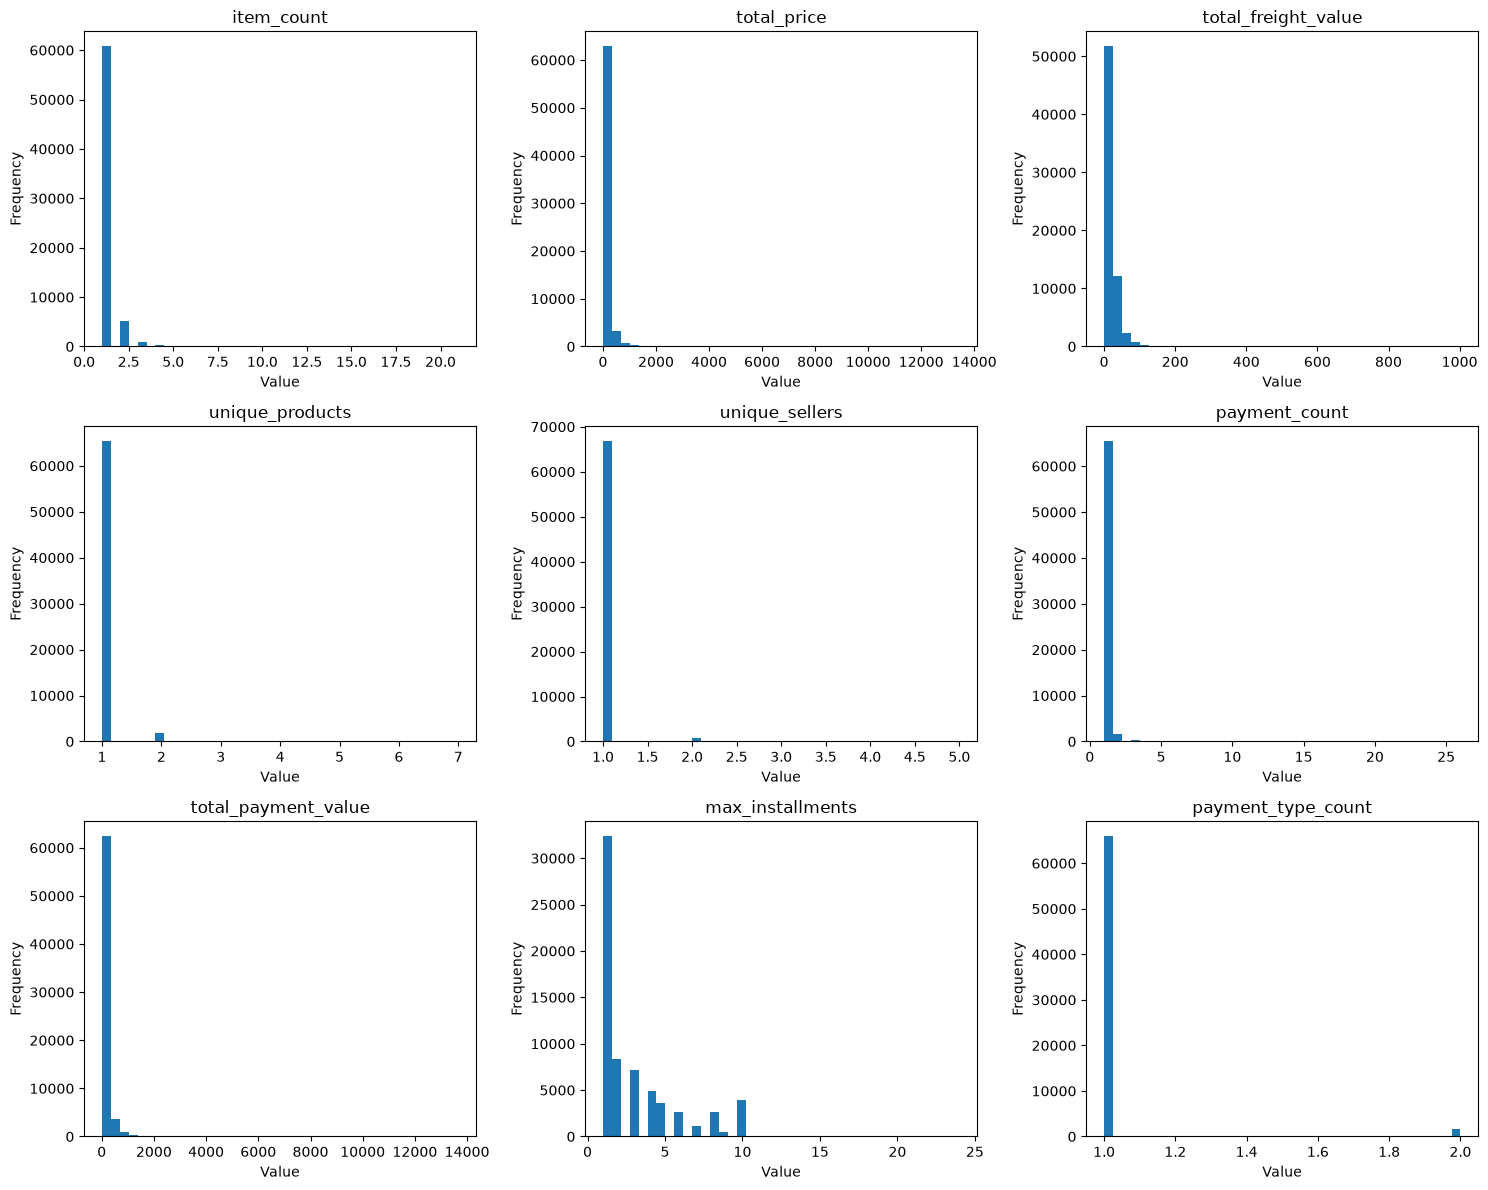

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    axes[i].hist(train[column].dropna(), bins=40)
    axes[i].set_title(column)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4.5 Distribution Interpretation
The histograms confirm that most numerical features are strongly right-skewed. Most orders have relatively small values, while a small number of observations extend far into the upper ranges.

The strongest effects are visible in the price, payment, freight, item, and payment-count features. These extreme values compress most observations into a small part of the plots. They will be examined further before deciding whether any treatment is needed during preprocessing.

### 4.6 Potential Outliers
I will use the interquartile range (IQR) rule to identify unusually high or low values in the numerical features. These observations will not be removed at this stage; the calculation is used only to understand their frequency.

In [10]:
outlier_summary = []

for column in numerical_columns:
    series = train[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) | (series > upper_bound)
    ]

    outlier_summary.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage": len(outliers) / len(series) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary["outlier_percentage"] = (
    outlier_summary["outlier_percentage"].round(2)
)

outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,item_count,1.0000,1.0000,6759,10.01
1,total_price,-110.1000,305.9000,5361,7.94
2,total_freight_value,-0.3000,38.1000,6629,9.82
3,unique_products,1.0000,1.0000,2210,3.27
4,unique_sellers,1.0000,1.0000,776,1.15
5,payment_count,1.0000,1.0000,2129,3.15
6,total_payment_value,-109.1525,346.2675,5308,7.86
7,max_installments,-3.5000,8.5000,4677,6.93
8,payment_type_count,1.0000,1.0000,1622,2.40


### 4.7 Outlier Interpretation
The IQR method identifies potential outliers in all numerical features. However, these values should not automatically be treated as errors.

For several count-based features, such as `item_count`, `unique_products`, `unique_sellers`, and `payment_count`, the interquartile range is zero because most orders have a value of 1. As a result, legitimate orders with values above 1 are flagged by the IQR rule.

The monetary features also contain relatively large upper-tail values, which is consistent with their strongly right-skewed distributions. No observations will be removed during EDA. Any transformations or outlier treatment will be considered later during preprocessing.

## 5. Target Variable Analysis
I will examine the distribution of `late_delivery` in the training set and evaluate the level of class imbalance before analyzing its relationships with the available features.

In [11]:
target_summary = (
    train["late_delivery"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(train) * 100
).round(2)

target_summary.index = ["On time (0)", "Late (1)"]

target_summary

,count,percentage
On time (0),62242,92.17
Late (1),5291,7.83


### 5.1 Target Distribution Interpretation
The target variable is imbalanced. Most training orders were delivered on time (92.17%), while 7.83% were delivered late.

Because late deliveries are the minority class, model evaluation should not rely on accuracy alone. Metrics such as precision, recall, F1-score, and the confusion matrix will also be important when evaluating the model.

### 5.2 Numerical Features by Delivery Outcome
I will compare the numerical features between on-time and late orders to identify potential differences associated with late delivery.

In [12]:
feature_by_target = (
    train
    .groupby("late_delivery")[numerical_columns]
    .median()
    .T
)

feature_by_target.columns = ["On time (0)", "Late (1)"]

feature_by_target

,On time (0),Late (1)
item_count,1.00,1.00
total_price,84.99,92.00
total_freight_value,16.61,18.23
unique_products,1.00,1.00
unique_sellers,1.00,1.00
payment_count,1.00,1.00
total_payment_value,103.11,115.89
max_installments,2.00,2.00
payment_type_count,1.00,1.00


### 5.3 Numerical Comparison Interpretation
The median values of most count-based features are similar for on-time and late orders. In both groups, a typical order contains one item, one product, one seller, and one payment.

Some differences appear in the monetary features. Late orders have higher median `total_price`, `total_freight_value`, and `total_payment_value` than on-time orders. These differences suggest that order value and freight cost may be related to delivery outcome, but further analysis is needed before drawing conclusions.

## 6. Categorical Feature Analysis
### 6.1 Late Delivery by Customer State
I will compare late-delivery rates across customer states to determine whether delivery outcomes vary geographically.

In [13]:
state_summary = (
    train
    .groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reset_index()
)

state_summary["late_rate"] = (
    state_summary["late_rate"] * 100
).round(2)

state_summary = state_summary.sort_values(
    "late_rate",
    ascending=False
)

state_summary

,customer_state,orders,late_orders,late_rate
1,AL,298,74,24.83
9,MA,548,107,19.53
21,RR,29,5,17.24
24,SE,246,42,17.07
5,CE,948,158,16.67
18,RJ,8967,1356,15.12
16,PI,348,49,14.08
4,BA,2307,301,13.05
14,PB,370,45,12.16
13,PA,718,87,12.12


### 6.2 Geography Interpretation
Late-delivery rates vary across customer states, which suggests that customer location may be useful for predicting delivery delays.

Some states have relatively few orders, so high late-delivery percentages in those states should be interpreted carefully. Customer state will be considered as a possible feature in the next notebook.

### 6.3 Late Delivery by Seller State
I will compare late-delivery rates across seller states to see whether seller location is also related to delivery delays.

In [14]:
seller_state_summary = (
    train
    .groupby("seller_state")
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reset_index()
)

seller_state_summary["late_rate"] = (
    seller_state_summary["late_rate"] * 100
).round(2)

seller_state_summary = seller_state_summary.sort_values(
    "late_rate",
    ascending=False
)

seller_state_summary

,seller_state,orders,late_orders,late_rate
0,AM,3,1,33.33
6,MA,63,19,30.16
2,CE,56,5,8.93
15,RJ,2693,235,8.73
16,RN,46,4,8.70
21,SP,47865,4077,8.52
4,ES,252,17,6.75
14,PR,5357,347,6.48
1,BA,409,24,5.87
3,DF,585,34,5.81


### 6.4 Seller State Interpretation
Late-delivery rates also vary by seller state.

Some states show high late-delivery rates, but several of them have very small numbers of orders, so those percentages should be interpreted carefully. States with larger order volumes, such as `SP` and `RJ`, provide more reliable comparisons.

Seller state will be considered as a possible feature for the model.

### 6.5 Customer and Seller State Match
I will check whether orders where the customer and seller are in the same state have a different late-delivery rate from orders where they are in different states.

In [15]:
train["same_state"] = (
    train["customer_state"] == train["seller_state"]
)

same_state_summary = (
    train
    .groupby("same_state")
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reset_index()
)

same_state_summary["late_rate"] = (
    same_state_summary["late_rate"] * 100
).round(2)

same_state_summary

,same_state,orders,late_orders,late_rate
0,False,44448,4267,9.60
1,True,23085,1024,4.44


### 6.6 State Match Interpretation
Orders where the customer and seller are in different states have a higher late-delivery rate (9.60%) than orders where they are in the same state (4.44%).

This suggests that geographic separation between the customer and seller may be related to delivery delays. A same-state indicator will be considered as a feature in the next notebook.

### 6.7 Delivery Distance
I will compare the customer–seller distance with the delivery outcome to see whether longer distances are associated with more late deliveries.

In [16]:
distance_summary = (
    train
    .groupby("late_delivery")["distance_km"]
    .agg(["count", "median", "mean"])
)

distance_summary.index = ["On time (0)", "Late (1)"]

distance_summary

,count,median,mean
On time (0),61931,438.303573,599.509107
Late (1),5257,559.955288,793.476573


### 6.8 Distance Interpretation
Late orders tend to travel longer distances than on-time orders.

The median customer–seller distance is about 438 km for on-time orders and about 560 km for late orders. The mean distance is also higher for late orders.

This suggests that delivery distance may be useful as a feature for predicting late delivery.

### 6.9 Late Delivery by Distance Range
I will group orders into distance ranges to see how the late-delivery rate changes as the customer–seller distance increases.

In [17]:
train["distance_group"] = pd.cut(
    train["distance_km"],
    bins=[0, 100, 500, 1000, 2000, float("inf")],
    labels=[
        "0-100 km",
        "100-500 km",
        "500-1000 km",
        "1000-2000 km",
        "2000+ km"
    ],
    include_lowest=True
)

distance_group_summary = (
    train
    .groupby("distance_group", observed=False)
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reset_index()
)

distance_group_summary["late_rate"] = (
    distance_group_summary["late_rate"] * 100
).round(2)

distance_group_summary

,distance_group,orders,late_orders,late_rate
0,0-100 km,11620,440,3.79
1,100-500 km,25926,1904,7.34
2,500-1000 km,18611,1598,8.59
3,1000-2000 km,7004,765,10.92
4,2000+ km,4027,550,13.66


### 6.10 Distance Range Interpretation
The late-delivery rate increases as the customer–seller distance becomes larger.

Orders traveling less than 100 km have a late-delivery rate of 3.79%, while orders traveling more than 2,000 km have a late-delivery rate of 13.66%.

This suggests that distance is strongly related to delivery outcome and should be considered as a feature in the next notebook.

### Categorical Cardinality and ZIP-Code Prefixes
I will check the number of unique values in the main categorical and geographic columns and look at the most common ZIP-code prefixes.

In [18]:
categorical_check = [
    "customer_state",
    "seller_state",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix"
]

for column in categorical_check:
    print(f"\n{column}")
    print("Unique values:", train[column].nunique())
    print(train[column].value_counts(dropna=False).head(10))


customer_state
Unique values: 27
customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
Name: count, dtype: int64

seller_state
Unique values: 22
seller_state
SP    47865
MG     5631
PR     5357
RJ     2693
SC     2579
RS     1285
DF      585
BA      409
GO      302
ES      252
Name: count, dtype: int64

customer_zip_code_prefix
Unique values: 13748
customer_zip_code_prefix
22790    113
22793     89
24220     82
24230     81
22775     80
29101     73
35162     69
22631     64
37200     63
35500     62
Name: count, dtype: int64

seller_zip_code_prefix
Unique values: 1681
seller_zip_code_prefix
14940.0    4754
9015.0     1497
15025.0    1133
5849.0     1125
3426.0     1004
13405.0     969
13232.0     951
8577.0      873
4160.0      840
4782.0      728
Name: count, dtype: int64


## 7. Date and Time Analysis
I will examine delivery patterns over time, including purchase month and weekday, to see whether late deliveries are more common during certain periods.

In [19]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.to_period("M")

monthly_delivery = (
    train
    .groupby("purchase_month")
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reset_index()
)

monthly_delivery["late_rate"] = (
    monthly_delivery["late_rate"] * 100
).round(2)

monthly_delivery

,purchase_month,orders,late_orders,late_rate
0,2016-09,1,1,100.00
1,2016-10,270,2,0.74
2,2016-12,1,0,0.00
3,2017-01,750,22,2.93
4,2017-02,1653,49,2.96
5,2017-03,2546,116,4.56
6,2017-04,2303,151,6.56
7,2017-05,3545,106,2.99
8,2017-06,3135,95,3.03
9,2017-07,3872,108,2.79


### 7.1 Monthly Pattern Interpretation
The late-delivery rate changes noticeably over time.

Some months, especially November 2017, February 2018, and March 2018, have much higher late-delivery rates than the surrounding months.

The very high percentage in September 2016 is based on only one order, so it is not representative.

This suggests that time-related features such as purchase month may be useful for the model.

### 7.2 Late Delivery by Purchase Weekday
I will check whether the day of the week when an order is placed is related to late delivery.

In [20]:
train["purchase_weekday"] = (
    train["order_purchase_timestamp"].dt.day_name()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_delivery = (
    train
    .groupby("purchase_weekday")
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_delivery["late_rate"] = (
    weekday_delivery["late_rate"] * 100
).round(2)

weekday_delivery

,purchase_weekday,orders,late_orders,late_rate
0,Monday,10736,923,8.60
1,Tuesday,10729,857,7.99
2,Wednesday,10339,778,7.52
3,Thursday,10005,725,7.25
4,Friday,9885,808,8.17
5,Saturday,7594,599,7.89
6,Sunday,8245,601,7.29


### 7.3 Weekday Interpretation
Late-delivery rates vary slightly across purchase weekdays.

Monday has the highest late-delivery rate at 8.60%, while Thursday and Sunday are among the lowest. However, the differences are relatively small compared with patterns such as customer–seller distance.

Purchase weekday may still be considered as a time-based feature.

### 7.4 Delivery Time
I will calculate the actual delivery time to understand how it differs between on-time and late orders.

This variable is used only for EDA and will not be used as a prediction feature because the actual delivery date is not available at prediction time.

In [21]:
train["delivery_days"] = (
    train["order_delivered_customer_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

delivery_time_summary = (
    train
    .groupby("late_delivery")["delivery_days"]
    .agg(["count", "median", "mean"])
)

delivery_time_summary.index = ["On time (0)", "Late (1)"]

delivery_time_summary

,count,median,mean
On time (0),62242,10.891030,11.920840
Late (1),5291,33.061331,36.222088


### 7.5 Delivery Time Interpretation
Late orders take much longer to reach the customer than on-time orders.

The median delivery time is about 10.9 days for on-time orders and about 33.1 days for late orders.

This confirms the difference between the two delivery outcomes. However, `delivery_days` will not be used as a model feature because it depends on the actual delivery date, which is only known after the order has been delivered.

### 7.6 Estimated Delivery Window
I will calculate the number of days between the purchase date and the estimated delivery date. Unlike actual delivery time, this information is available before the final delivery and can be considered as a possible model feature.

In [22]:
train["estimated_window_days"] = (
    train["order_estimated_delivery_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

estimated_window_summary = (
    train
    .groupby("late_delivery")["estimated_window_days"]
    .agg(["count", "median", "mean"])
)

estimated_window_summary.index = ["On time (0)", "Late (1)"]

estimated_window_summary

,count,median,mean
On time (0),62242,23.660856,24.641209
Late (1),5291,23.431875,24.080616


### 7.7 Estimated Window Interpretation
The estimated delivery window is very similar for on-time and late orders.

The median is about 23.7 days for on-time orders and 23.4 days for late orders. This suggests that the estimated window alone may not be a strong predictor of late delivery, although it can still be considered during feature engineering.

### 7.8 Monthly Late-Delivery Trend
I will visualize the monthly late-delivery rate and save the chart as an EDA artifact.

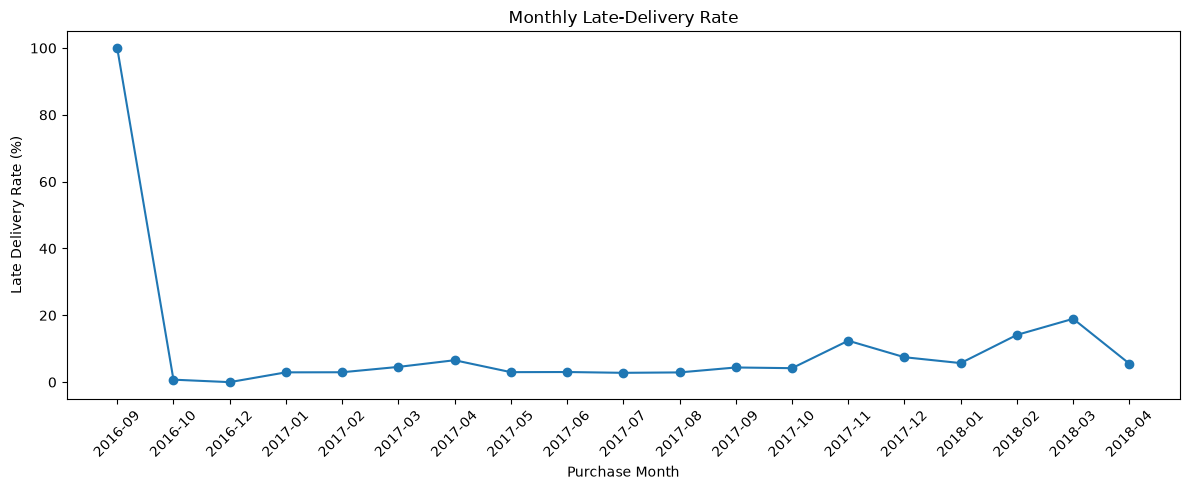

In [23]:
monthly_chart = monthly_delivery.copy()
monthly_chart["purchase_month"] = monthly_chart["purchase_month"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_chart["purchase_month"],
    monthly_chart["late_rate"],
    marker="o"
)

plt.title("Monthly Late-Delivery Rate")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "artifacts/monthly_late_delivery_rate.png",
    bbox_inches="tight"
)

plt.show()

### 7.9 Holiday Effect
I will check whether orders placed on Brazilian public holidays have a different late-delivery rate from orders placed on other days.

In [24]:
import holidays

brazil_holidays = holidays.Brazil(
    years=range(
        train["order_purchase_timestamp"].dt.year.min(),
        train["order_purchase_timestamp"].dt.year.max() + 1
    )
)

train["is_holiday"] = (
    train["order_purchase_timestamp"].dt.date
    .isin(brazil_holidays)
)

holiday_summary = (
    train
    .groupby("is_holiday")
    .agg(
        orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
    .reset_index()
)

holiday_summary["late_rate"] = (
    holiday_summary["late_rate"] * 100
).round(2)

holiday_summary

,is_holiday,orders,late_orders,late_rate
0,False,66462,5234,7.88
1,True,1071,57,5.32


### 7.10 Holiday Interpretation
Orders placed on public holidays have a lower late-delivery rate (5.32%) than orders placed on non-holiday dates (7.88%).

However, holiday orders make up a relatively small part of the training data, so this difference should be interpreted carefully. Holiday status may still be considered as a possible time-based feature.

## 8. Relationships Between Numerical Features
I will check correlations between the numerical features and the target to identify relationships that may be useful for modeling.

In [25]:
correlation_columns = [
    "item_count",
    "total_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "max_installments",
    "payment_type_count",
    "distance_km",
    "estimated_window_days",
    "late_delivery"
]

correlations = (
    train[correlation_columns]
    .corr(numeric_only=True)["late_delivery"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_late_delivery")
)

correlations

,correlation_with_late_delivery
late_delivery,1.000000
distance_km,0.087549
total_freight_value,0.049654
total_payment_value,0.025528
total_price,0.021834
max_installments,0.017412
payment_count,-0.006094
payment_type_count,-0.006499
item_count,-0.015031
estimated_window_days,-0.018778


### 8.1 Correlation Interpretation
The numerical features have weak linear correlations with `late_delivery`.

`distance_km` has the strongest positive correlation with the target, followed by `total_freight_value`. Most other numerical features have correlations close to zero.

These correlations should be interpreted together with the earlier group comparisons, since some useful relationships may not be strongly linear.

## 9. Main Findings
The main findings from the training data are:

- The target is imbalanced, with 7.83% late orders.
- Most numerical features are strongly right-skewed and contain large upper-tail values.
- Late orders tend to have higher price, freight, and payment values.
- Customer and seller geography is related to delivery outcome.
- Orders where the customer and seller are in different states have a higher late-delivery rate.
- Customer–seller distance shows a clear relationship with late delivery, with higher late rates at longer distances.
- Late-delivery rates change over time, especially by purchase month.
- Purchase weekday and holiday status show smaller differences.
- Actual delivery time strongly differs between late and on-time orders, but it must not be used as a model feature because it is only known after delivery.
- The estimated delivery window is similar for late and on-time orders and may be less informative on its own.

These findings will guide feature engineering in the next notebook.

## 10. Save EDA Findings
I will save a short summary of the main EDA findings so the next steps can use them without rerunning the full analysis.

In [26]:
eda_findings = """
MLOps Training 2026/2027 — Task 2
Notebook 4: EDA Findings

- The training target is imbalanced: 7.83% of orders are late.
- Most numerical features are strongly right-skewed.
- Price, freight, and payment values tend to be higher for late orders.
- Customer and seller geography are related to late delivery.
- Orders where customer and seller are in different states have a higher late-delivery rate.
- Longer customer-seller distance is associated with higher late-delivery rates.
- Late-delivery rates vary noticeably by purchase month.
- Weekday and holiday effects are smaller.
- Actual delivery time differs strongly between late and on-time orders, but it must not be used as a prediction feature because it would cause data leakage.
- Estimated delivery window is similar for both classes and may be less informative on its own.
"""

with open(
    "artifacts/eda_findings.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(eda_findings)

print("EDA findings saved successfully!")

EDA findings saved successfully!


## 11. Conclusion
The training split was explored without using the validation or test sets. The analysis identified class imbalance, skewed numerical features, geographic patterns, time-related patterns, and several possible feature candidates.

The saved findings and charts will be used to guide feature engineering in Notebook 5.